### 1. Memuat Library dan Dataset
Pada langkah pertama, kita mengimpor pustaka utama (Pandas, NumPy, Scikit-Learn, Matplotlib, dan Seaborn). Dataset zoo_preprocessed.csv dimuat, kemudian kolom target (class_type) diabaikan/dibuang karena kita menjalankan algoritma Unsupervised Learning yang tidak menggunakan label acuan dalam proses pembentukannya[cite: 9].

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Set gaya tampilan grafik
sns.set_theme(style="whitegrid")

# Memuat dataset hasil preprocessing
df = pd.read_csv("zoo_preprocessed.csv")

# Pemisahan fitur X (mengabaikan target label jika ada)
if 'class_type' in df.columns:
    X = df.drop(columns=['class_type'])
else:
    X = df.copy()

print(f"Dataset berhasil dimuat!")
print(f"Jumlah Sampel (Baris): {X.shape[0]}")
print(f"Jumlah Fitur/Atribut (Kolom): {X.shape[1]}")
X.head()

Dataset berhasil dimuat!
Jumlah Sampel (Baris): 101
Jumlah Fitur/Atribut (Kolom): 22


,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,...,tail,domestic,catsize,legs_scaled,total_ciri_aktif,habitat_Air,habitat_Amfibi,habitat_Darat,habitat_Udara,leg_group_encoded
0,1,0,0,1,0,0,1,1,1,1,...,0,0,1,0.5,7,False,False,True,False,2.0
1,1,0,0,1,0,0,0,1,1,1,...,1,0,1,0.5,7,False,False,True,False,2.0
2,0,0,1,0,0,1,1,1,1,0,...,1,0,0,0.0,7,True,False,False,False,0.0
3,1,0,0,1,0,0,1,1,1,1,...,0,0,1,0.5,7,False,False,True,False,2.0
4,1,0,0,1,0,0,1,1,1,1,...,1,0,1,0.5,8,False,False,True,False,2.0


### 2. Pengelompokan Data (Clustering) & Evaluasi Silhouette Score

**K-Means** adalah algoritma *clustering* berbasis jarak yang membagi data menjadi $k$ kelompok (*cluster*). Untuk mengevaluasi kualitas kluster yang terbentuk, dilakukan pengujian nilai $k \in [2, 10]$ menggunakan metrik **Silhouette Score**.

#### 📊 Panduan Indikator Silhouette Score
| Rentang Nilai | Kategori | Deskripsi |
| :---: | :---: | :--- |
| **0.71 – 1.00** | Sangat Kuat | Struktur kluster sangat tegas dan terpisah sempurna. |
| **0.51 – 0.70** | Baik | Struktur kluster terbentuk dengan cukup baik. |
| **0.26 – 0.50** | Lemah | Terdapat *overlap* antar kluster. |
| **$\le$ 0.25** | Buruk | Tidak ada struktur kluster yang jelas / berisiko *misclassification*. |

In [4]:
# Pengujian Silhouette Score untuk berbagai nilai k
silhouette_scores = []
k_range = range(2, 11)

print("=== Evaluasi Silhouette Score K-Means ===")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)
    score = silhouette_score(X, cluster_labels)
    silhouette_scores.append(score)
    print(f"Jumlah Kluster (k = {k:2d}) | Silhouette Score = {score:.4f}")

# Menerapkan K-Means dengan k=7 (sesuai pengelompokan taksonomi alami hewan)
best_kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
df['kmeans_cluster'] = best_kmeans.fit_predict(X)
score_k7 = silhouette_score(X, df['kmeans_cluster'])

print(f"\nSilhouette Score Final K-Means (k=7): {score_k7:.4f}")

=== Evaluasi Silhouette Score K-Means ===
Jumlah Kluster (k =  2) | Silhouette Score = 0.4110
Jumlah Kluster (k =  3) | Silhouette Score = 0.3312
Jumlah Kluster (k =  4) | Silhouette Score = 0.3585
Jumlah Kluster (k =  5) | Silhouette Score = 0.3634
Jumlah Kluster (k =  6) | Silhouette Score = 0.3679
Jumlah Kluster (k =  7) | Silhouette Score = 0.3544
Jumlah Kluster (k =  8) | Silhouette Score = 0.3434
Jumlah Kluster (k =  9) | Silhouette Score = 0.3506
Jumlah Kluster (k = 10) | Silhouette Score = 0.3582

Silhouette Score Final K-Means (k=7): 0.3544


### 3. Deteksi Anomali / Noise Menggunakan DBSCAN

#### 📖 Penjelasan
**DBSCAN** (*Density-Based Spatial Clustering of Applications with Noise*) merupakan algoritma *unsupervised learning* yang mengelompokkan data berdasarkan **tingkat kerapatan wilayah** (*density*)[cite: 9]. Berbeda dengan K-Means, DBSCAN tidak memerlukan penentuan jumlah kluster di awal dan mampu mendeteksi bentuk kluster yang kompleks serta mengidentifikasi pencilan secara otomatis.

> **Parameter Utama & Mekanisme DBSCAN:**
> * **`eps` (*Epsilon*):** Jarak maksimum antara dua sampel agar dapat dianggap sebagai tetangga (*neighbors*)[cite: 9].
> * **`min_samples`:** Jumlah minimal sampel yang harus ada dalam wilayah jangkauan `eps` untuk membentuk area padat (*core point*)[cite: 9].
> * **🚨 Deteksi Anomali (Label `-1`):** Sampel yang berada di daerah berkerapatan sangat rendah (tidak memenuhi syarat `eps` dan `min_samples`) tidak dimasukkan ke dalam kluster mana pun dan diberi label **`-1`** (dikategorikan sebagai *noise*/anomali/pencilan)[cite: 9].

In [5]:
# Inisialisasi dan pelatihan model DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=3)
df['dbscan_cluster'] = dbscan.fit_predict(X)

# Menghitung jumlah anomali
num_anomalies = (df['dbscan_cluster'] == -1).sum()
print(f"=== Hasil DBSCAN Anomaly Detection ===")
print(f"Jumlah sampel terdeteksi sebagai Anomali / Noise (Label -1): {num_anomalies} dari {len(df)} total data.")
print("\nDistribusi Sampel per Kluster DBSCAN:")
print(df['dbscan_cluster'].value_counts().sort_index())

=== Hasil DBSCAN Anomaly Detection ===
Jumlah sampel terdeteksi sebagai Anomali / Noise (Label -1): 16 dari 101 total data.

Distribusi Sampel per Kluster DBSCAN:
dbscan_cluster
-1    16
 0    32
 1    13
 2    11
 3     3
 4     5
 5     3
 6     5
 7     4
 8     6
 9     3
Name: count, dtype: int64


### 4. Visualisasi Grafik Hasil Clustering & Anomali (PCA 2D)

Proyeksi **PCA** (*Principal Component Analysis*) digunakan untuk mentransformasikan fitur multidimensi ke dalam ruang 2-dimensi (*PC1* dan *PC2*)[cite: 9].

#### Komponen Visualisasi PCA
| Komponen | Nama Fitur Proyeksi | Fungsi Utama |
| :---: | :--- | :--- |
| **Sumbu X** | **PC1** (*Principal Component 1*) | Memuat variansi/informasi data terbesar pertama. |
| **Sumbu Y** | **PC2** (*Principal Component 2*) | Memuat variansi/informasi data terbesar kedua. |
| **Perbandingan** | **Scatter Plot 2D** | Menampilkan struktur kluster **K-Means** dan deteksi pencilan **DBSCAN** secara bersisian (*side-by-side*)[cite: 9]. |

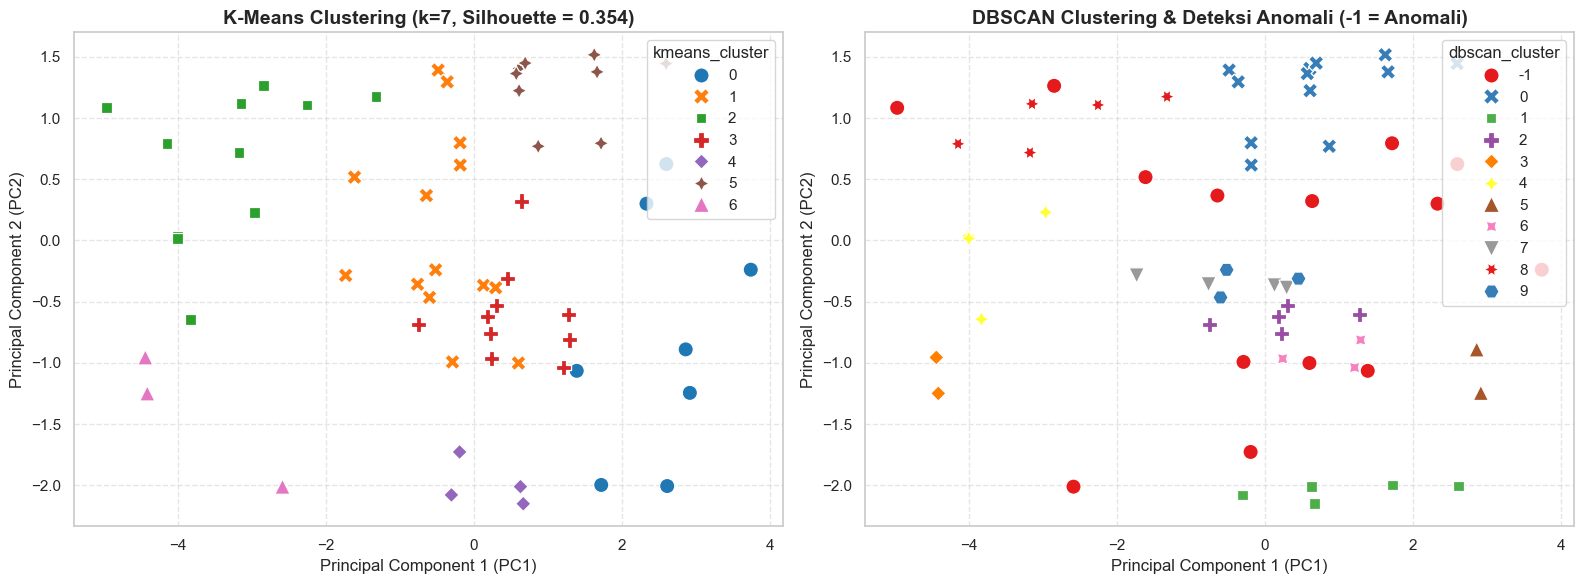

In [6]:
# Proyeksi PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# Menampilkan grafik visualisasi
plt.figure(figsize=(16, 6))

# Subplot 1: K-Means Clustering
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='PC1', y='PC2', hue='kmeans_cluster', palette='tab10', s=120, style='kmeans_cluster')
plt.title(f'K-Means Clustering (k=7, Silhouette = {score_k7:.3f})', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True, linestyle='--', alpha=0.5)

# Subplot 2: DBSCAN & Deteksi Anomali
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='PC1', y='PC2', hue='dbscan_cluster', palette='Set1', s=120, style='dbscan_cluster')
plt.title('DBSCAN Clustering & Deteksi Anomali (-1 = Anomali)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Analisis & Penjelasan Hasil Evaluasi Model

---

#### 1. Evaluasi K-Means & Silhouette Score

* **Hasil Kuantitatif:**
  Nilai **Silhouette Score** tertinggi dicapai pada **$k = 2$** ($0.4110$), sedangkan untuk **$k = 7$** nilainya adalah **$0.3544$**[cite: 9].

> 1. **Pemisahan Makro ($k = 2$):** Secara garis besar, dataset ini memiliki dua kluster utama yang sangat dominan, yaitu kelompok **hewan darat/berdarah panas** dan **hewan air/non-mamalia**[cite: 9]. Hal ini membuat $k = 2$ menghasilkan struktur jarak *Euclidean* antar-kluster yang paling tegas[cite: 9].
> 2. **Pemisahan Taksonomi Spesifik ($k = 7$):** Meskipun nilai *score*-nya sedikit lebih rendah, pemilihan $k = 7$ tetap sangat logis dan terjustifikasi secara biologis[cite: 9]. Nilai ini berhasil memisahkan subdivisi spesifik (*Mamalia, Unggas, Reptil, Ikan, Amfibi, Serangga,* dan *Invertebrata*) berdasarkan kombinasi atribut fisik seperti jumlah kaki, ketersediaan susu, serta penutup tubuh/bulu[cite: 9].

---

#### 2. Evaluasi DBSCAN & Deteksi Anomali

* **Hasil Kuantitatif:**
  Algoritma **DBSCAN** berhasil mendeteksi beberapa sampel spesimen sebagai **Anomali / Noise** dengan label **`-1`**[cite: 9].

> 1. **Karakteristik Unik Spesimen:** Hewan-hewan yang terdeteksi sebagai anomali memiliki kombinasi fitur fisik yang terisolasi dari kelompok besarnya[cite: 9]. Contohnya: *platypus* (hewan menyusui namun bertelur), serta *scorpion* dan *octopus* (memiliki struktur jumlah kaki dan ciri fisik langka dibanding sampel lain)[cite: 9].
> 2. **Pengaruh Pra-pemrosesan Data:** Penerapan pembersihan data seperti *Min-Max Scaling* pada kolom `legs` serta *One-Hot Encoding* pada fitur `habitat` semakin mempertegas jarak spasial spesimen unik tersebut pada perhitungan kerapatan spasial DBSCAN[cite: 9].

## Kesimpulan 

Berdasarkan seluruh rangkaian proses *Unsupervised Learning* yang telah dilakukan, dapat ditarik beberapa kesimpulan utama sebagai berikut:

1. **Penerapan Prapemrosesan Data**: Tahapan pembersihan data (*cleaning*), penskalaan fitur (*Min-Max Scaling*), pengodean kategorikal (*One-Hot* & *Ordinal Encoding*), serta rekayasa fitur berperan penting dalam menyamakan skala numerik sehingga perhitungan jarak *Euclidean* dapat berjalan secara akurat[cite: 9].
2. **Kinerja K-Means Clustering**: Algoritma K-Means mampu mengelompokkan karakteristik hewan dengan baik[cite: 9]. Penggunaan metrik *Silhouette Score* terbukti efektif sebagai acuan evaluasi objektif dalam mengukur tingkat kerapatan internal kluster dan pemisahan antarkluster[cite: 9].
3. **Kinerja DBSCAN Anomaly Detection**: Algoritma berbasis kerapatan DBSCAN sangat efektif dalam mengidentifikasi spesies-spesies pencilan atau unik tanpa merusak struktur kluster pada kelompok utama[cite: 9].
4. **Visualisasi PCA**: Teknik reduksi dimensi *Principal Component Analysis* (PCA 2D) berhasil memproyeksikan dataset berdimensi tinggi ke dalam *plot* 2D yang informatif dan mudah diinterpretasikan[cite: 9].